In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
 
np.random.seed(0)

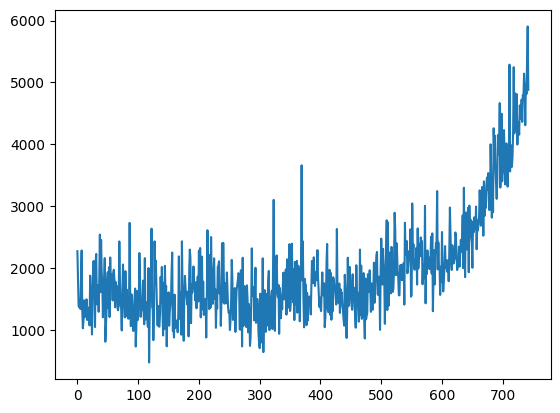

In [41]:
y = pd.read_csv("web_traffic.tsv", sep="\t",header=None).iloc[:,1]
y = y[~np.isnan(y)]
x = np.linspace(y.min(), y.max(), len(y)).reshape(-1, 1)
plt.plot(y)
plt.show()

In [42]:
def testDegreeX(x,y,degree, plot=False):
    poly = PolynomialFeatures(degree=degree)
    x_poly2 = poly.fit_transform(x)

    model2 = LinearRegression()
    model2.fit(x_poly2, y)

    a2=model2.coef_
    b2=model2.intercept_

    y_pred = model2.predict(x_poly2)
    score = round(model2.score(x_poly2,y) * 100, 2)
    if plot:
        plt.scatter(x, y, color= 'blue')
        plt.plot(x,y_pred,color='red')
        plt.title(f" Degree = {degree} : Score={score:.3f}")
        plt.show()
    return score, a2, b2

In [43]:
results = []
for degree in range(1,11):
    score, a, b = testDegreeX(x,y,degree)
    print(f"Grado: {degree} - score: {score}%")
    results.append((degree, score, a, b))

Grado: 1 - score: 41.91%
Grado: 2 - score: 67.07%
Grado: 3 - score: 74.43%
Grado: 4 - score: 75.99%
Grado: 5 - score: 76.67%
Grado: 6 - score: 76.96%
Grado: 7 - score: 77.1%
Grado: 8 - score: 77.16%
Grado: 9 - score: 77.18%
Grado: 10 - score: 77.17%


In [44]:
sorted(results, key=lambda x: x[1], reverse=True)[0][:2]

(9, 77.18)

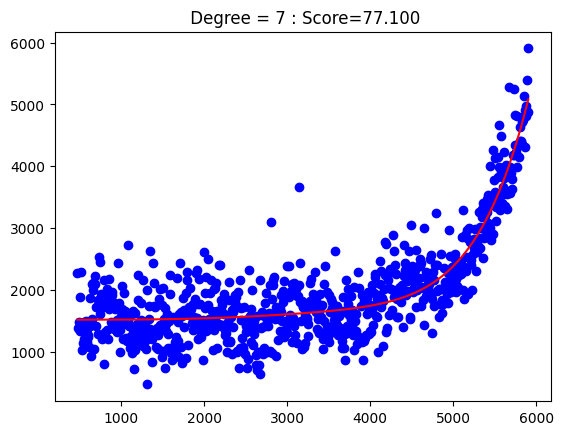

In [48]:
score, a, b = testDegreeX(x,y,7,plot=True)

In [49]:
print(a)
print(b)

[ 0.00000000e+00  1.53514018e-22  1.69719289e-25  5.06913777e-22
  1.21968220e-18  1.94573406e-15 -8.21615458e-19  9.75509197e-23]
1519.7652774116505


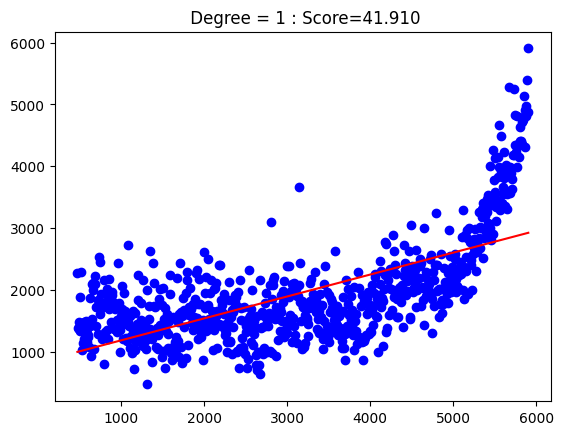

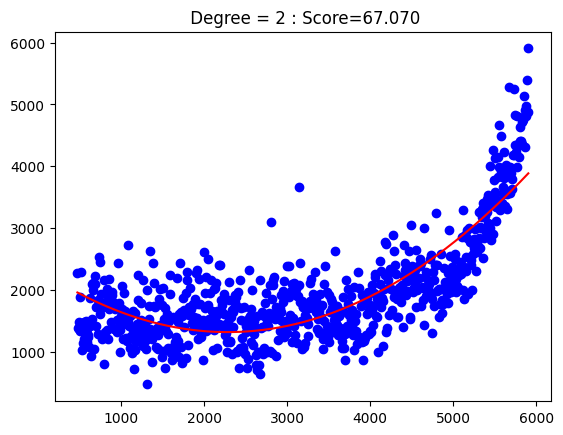

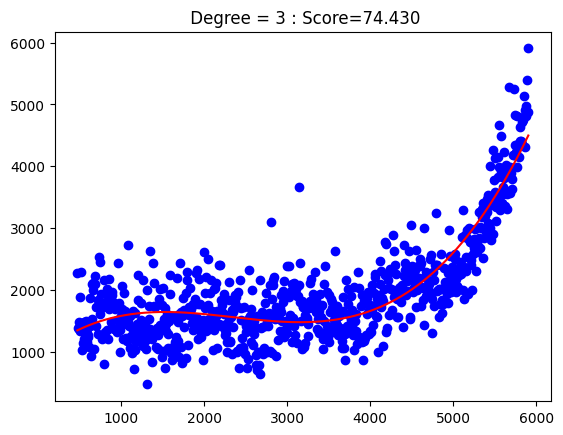

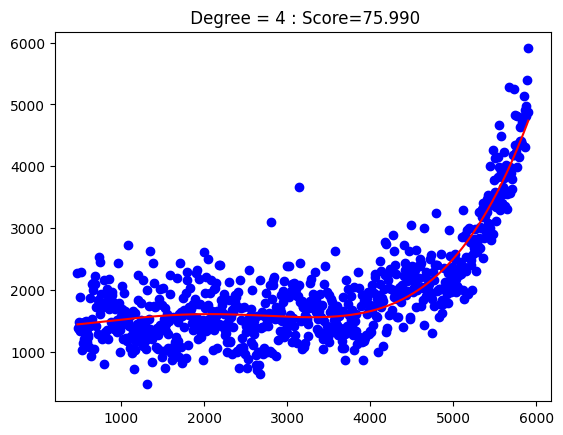

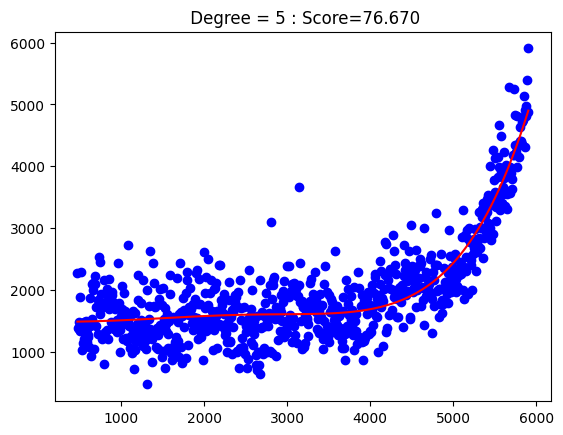

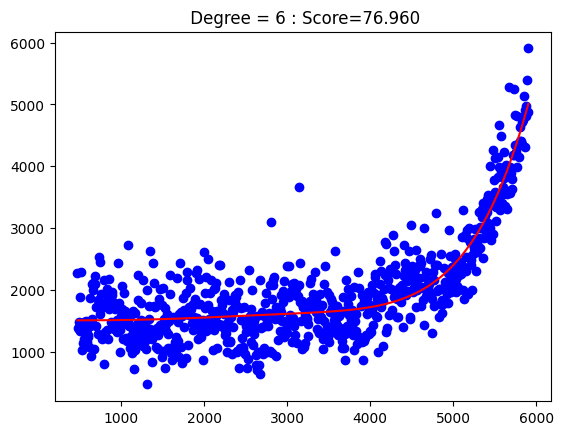

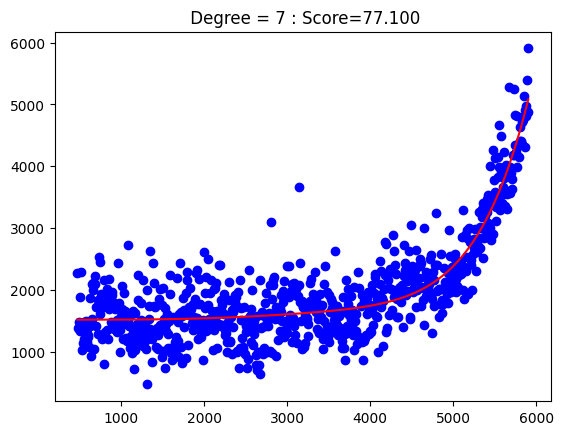

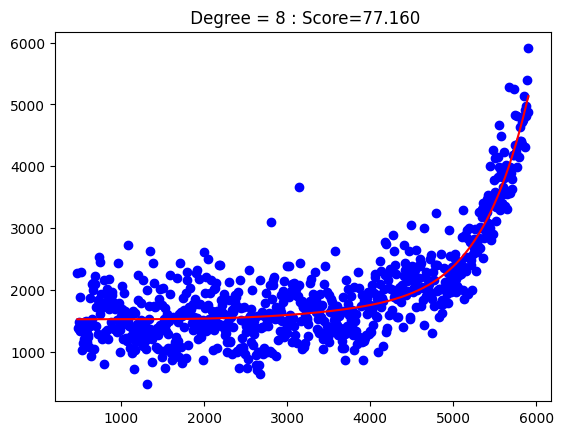

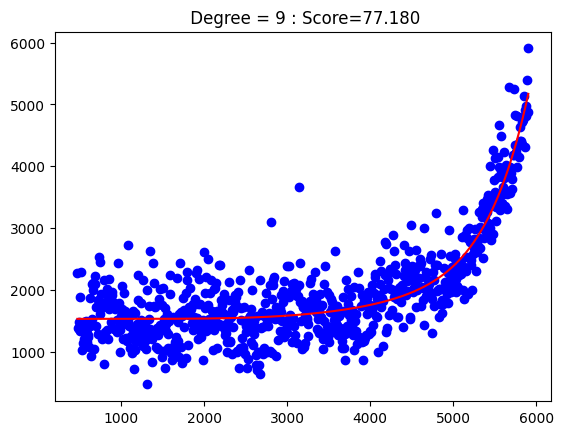

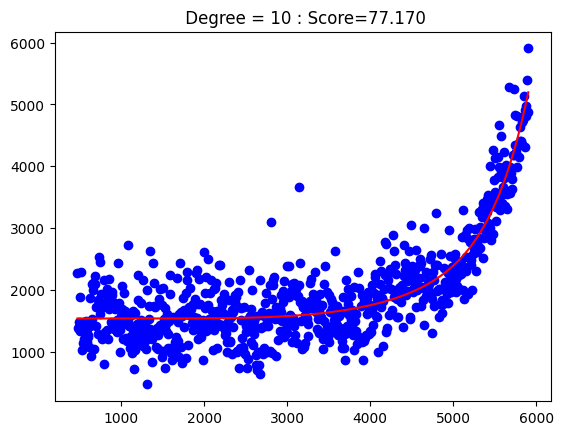

[(41.91, array([0.        , 0.35447145]), np.float64(831.7565388177793)),
 (67.07,
  array([ 0.00000000e+00, -8.92612677e-01,  1.95529026e-04]),
  np.float64(2337.783618110084)),
 (74.43,
  array([ 0.00000000e+00,  1.10539353e+00, -5.37746794e-04,  7.66463699e-08]),
  np.float64(937.6154996933346)),
 (75.99,
  array([ 0.00000000e+00,  1.18086636e-07,  2.06573208e-04, -1.08506326e-07,
          1.51870157e-11]),
  np.float64(1408.4055535490997)),
 (76.67,
  array([ 0.00000000e+00,  1.03822312e-14,  2.78853783e-11,  4.33383265e-08,
         -2.15946784e-11,  2.88932473e-15]),
  np.float64(1485.0097853075604)),
 (76.96,
  array([ 0.00000000e+00, -5.96644047e-19,  2.41122726e-18,  5.84077260e-15,
          9.11489925e-12, -4.19788938e-15,  5.31960236e-19]),
  np.float64(1508.6811954725392)),
 (77.1,
  array([ 0.00000000e+00,  1.53514018e-22,  1.69719289e-25,  5.06913777e-22,
          1.21968220e-18,  1.94573406e-15, -8.21615458e-19,  9.75509197e-23]),
  np.float64(1519.7652774116505)),
 (

In [47]:
[testDegreeX(x,y,i, True) for i in range(1,11)]